In [18]:
import pandas as pd


data = pd.read_csv("/content/weather_classification_data.csv")

In [19]:
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [20]:
data.tail()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy
13199,-5.0,38,0.0,92.0,overcast,1015.37,5,Autumn,10.0,mountain,Rainy


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Weather Type', ylabel='count'>

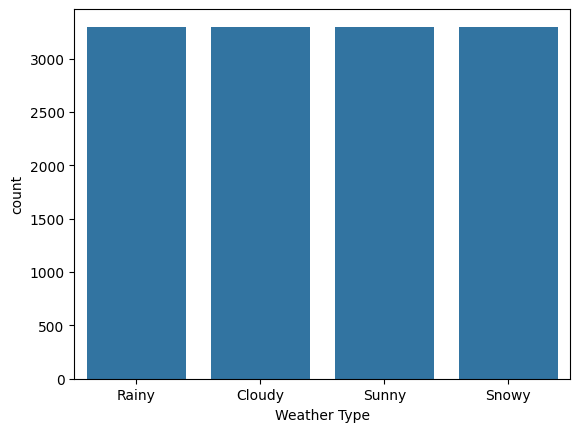

In [23]:
sns.countplot(x="Weather Type" , data = data )

Shows whether classes like Sunny, Rainy, Cloudy are balanced or imbalanced

<Axes: xlabel='Temperature', ylabel='Count'>

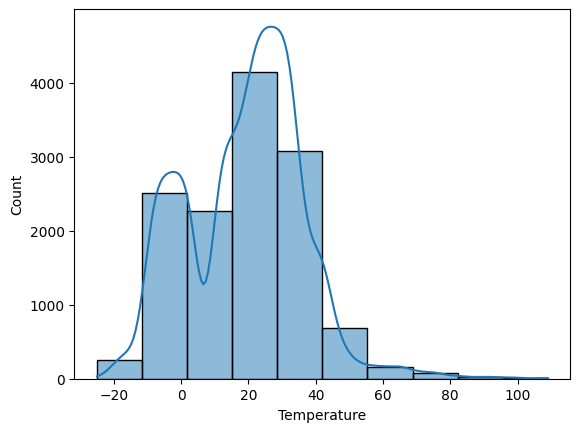

In [24]:
sns.histplot(data= data , x = "Temperature" , bins=10 , kde = True)

Helps identify typical temperature ranges and outliers

<Axes: xlabel='Weather Type', ylabel='Humidity'>

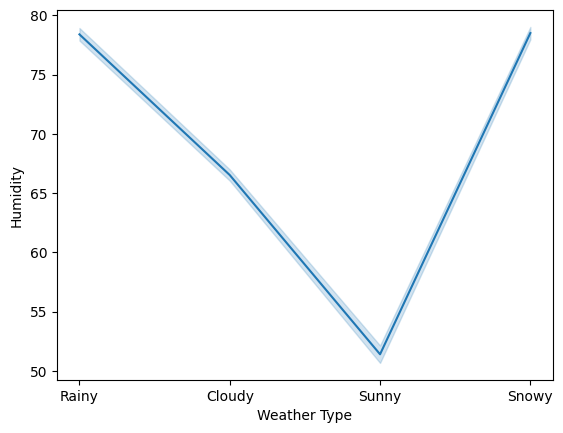

In [25]:
sns.lineplot(x='Weather Type', y='Humidity', data=data )

<Axes: xlabel='Temperature', ylabel='Humidity'>

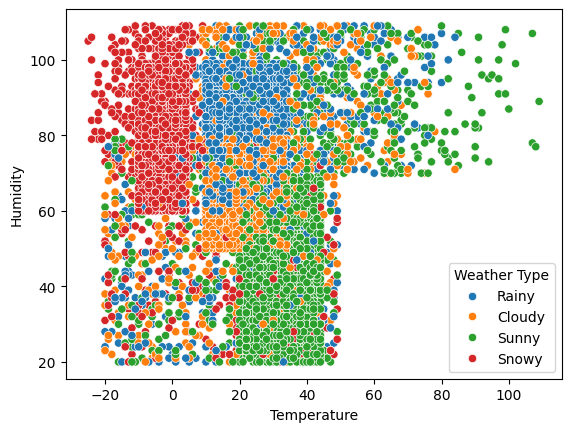

In [26]:
sns.scatterplot(
    x='Temperature',
    y='Humidity',
    hue='Weather Type',
    data=data
)

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["Weather Type"] = le.fit_transform(data["Weather Type"])
data["Cloud Cover"] = le.fit_transform(data["Cloud Cover"])
data["Season"] = le.fit_transform(data["Season"])
data["Location"] = le.fit_transform(data["Location"])



In [28]:
data.head()


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


<Axes: xlabel='Location', ylabel='Temperature'>

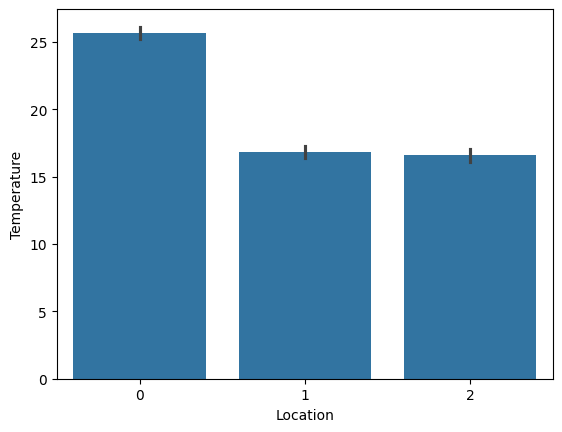

In [29]:
sns.barplot(data = data , x ="Location" , y = "Temperature"  )

In [30]:
X = data.drop("Weather Type", axis=1)
y = data["Weather Type"]


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [42]:
from sklearn.preprocessing import StandardScaler

scaler_lr = StandardScaler()

X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr = scaler_lr.transform(X_test)


In [43]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000
)

lr.fit(X_train_lr, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [44]:
y_pred_lr = lr.predict(X_test_lr)


In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.8545454545454545

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       660
           1       0.84      0.86      0.85       660
           2       0.90      0.91      0.91       660
           3       0.87      0.81      0.84       660

    accuracy                           0.85      2640
   macro avg       0.86      0.85      0.85      2640
weighted avg       0.86      0.85      0.85      2640


Confusion Matrix:
 [[551  62  12  35]
 [ 35 570  36  19]
 [ 24   8 602  26]
 [ 71  40  16 533]]


#KNN

In [46]:
from sklearn.preprocessing import StandardScaler

scaler_knn = StandardScaler()

X_train_knn = scaler_knn.fit_transform(X_train)
X_test_knn = scaler_knn.transform(X_test)


In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train)


KNeighborsClassifier()

In [48]:
y_pred_knn = knn.predict(X_test_knn)


In [49]:
print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred_knn))


KNN Accuracy: 0.8988636363636363

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       660
           1       0.87      0.91      0.89       660
           2       0.94      0.92      0.93       660
           3       0.94      0.89      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640


Confusion Matrix:
 [[585  55   8  12]
 [ 31 598  21  10]
 [ 26  17 604  13]
 [ 46  21   7 586]]


In [53]:
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


In [54]:
import numpy as np

X_unseen = np.array([
    [32.0, 65, 12.5, 20, 3 , 1009.5, 6,1 ,  8.0 ,2]
])


In [58]:
X_unseen_scaled = scaler_lr.transform(X_unseen)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [60]:
logistic_pred = lr.predict(X_unseen_scaled)
print("Logistic predictions:", logistic_pred)


Logistic predictions: [0]


In [62]:
knn_pred = knn.predict(X_unseen_scaled)
print("KNN predictions:", knn_pred)


KNN predictions: [0]
